# STAIR-v4 (SGInit): SG-URInit — Semantically Guaranteed User Initialization

**Key Innovation (v4 over v3.1):** Replace sparse `R_left @ mfeats` user init with SG-URInit (SIGIR'26): two-signal aggregation capturing both *local* item-level semantics (sym-normalized LightGCN-style) and *global* cluster-level context (K-Means centroid fallback), mixed with λ=0.1, then scale-aligned to item embedding norm.

| Parameter | v3.1 | v4 |
|---|---|---|
| Item Graph | ClipFuse-Consensus (unchanged) | ClipFuse-Consensus (unchanged) |
| User Init | R_left @ mfeats | SG-URInit (local + cluster) |
| K (clusters) | — | 8 |
| λ (local weight) | — | 0.1 |
| Scale alignment | No | Yes (matched to item norm) |

In [4]:
# Cell 1: Setup & Install
import os, shutil

os.chdir('/kaggle/working')

repo = 'STAIR-Enhanced'
if os.path.exists(repo):
    shutil.rmtree(repo)
os.system('git clone https://github.com/ThanhChuong12/STAIR-Enhanced.git')

os.system('pip install nvidia-ml-py -q')
os.system('pip install torchdata==0.6.1 --no-deps -q')
os.system('pip install freerec==0.9.7 -q')
os.system('pip install torch_geometric -q')   # required by freerec.graph
os.system('pip install scikit-learn -q')      # K-Means for SG-URInit
os.system('pip install prettytable -q')

import torch, platform, freerec
print('Python  :', platform.python_version())
print('PyTorch :', torch.__version__)
print('CUDA    :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU     :', torch.cuda.get_device_name(0))
print('freerec :', freerec.__version__)
print('sklearn :', __import__('sklearn').__version__)
print('Environment ready')


Cloning into 'STAIR-Enhanced'...


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.8 MB/s eta 0:00:00
Python  : 3.12.13
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
freerec : 0.9.7
sklearn : 1.6.1
Environment ready


In [5]:
# Cell 2: Copy dataset files
import os, shutil

DATA_ROOT = '/kaggle/data'
os.makedirs(DATA_ROOT, exist_ok=True)

def copy_dataset(keywords, full_name):
    dest = os.path.join(DATA_ROOT, full_name)
    os.makedirs(dest, exist_ok=True)
    copied = []
    for root, _, files in os.walk('/kaggle/input'):
        if any(kw.lower() in root.lower() for kw in keywords):
            for f in files:
                if f.endswith(('.npy', '.pkl', '.txt', '.inter', '.item')):
                    shutil.copy(os.path.join(root, f), os.path.join(dest, f))
                    copied.append(f)
    print(f'[{full_name}] {len(copied)} files copied')

copy_dataset(['baby', 'amazon2014baby'],     'Amazon2014Baby_550_MMRec')
copy_dataset(['sports', 'amazon2014sports'], 'Amazon2014Sports_550_MMRec')
print('Data ready at', DATA_ROOT)


[Amazon2014Baby_550_MMRec] 5 files copied
[Amazon2014Sports_550_MMRec] 5 files copied
Data ready at /kaggle/data


In [6]:
# Cell 3: Train STAIR-v4 on Baby
import subprocess, time

os.chdir('/kaggle/working/STAIR-Enhanced')

cmd_baby = [
    'python', 'main_v4.py',
    '--root', '/kaggle/data',
    '--dataset', 'Amazon2014Baby_550_MMRec',
    '--epochs', '500',
    '--batch-size', '1024',
    '--embedding-dim', '64',
    '--num-layers', '3',
    '--num-neighbors', '5-1',
    '--conf-delta', '0.3',
    '--conf-temp', '1.0',
    '--alpha-consensus', '0.5',
    '--sg-num-clusters', '8',
    '--sg-lambda', '0.1',
    '--optimizer', 'adamwsevo',
    '--lr', '1e-3',
    '--weight-decay', '0.1',
    '--seed', '1',
]

log_baby = '/kaggle/working/log_stair_v4_baby.txt'
print(f'Training STAIR-v4 (SGInit) on Baby ...')
t0 = time.time()
with open(log_baby, 'w') as f:
    proc = subprocess.run(cmd_baby, stdout=f, stderr=subprocess.STDOUT, text=True)
elapsed = (time.time() - t0) / 60
print(f'Done in {elapsed:.1f} min | rc={proc.returncode}')

# Print last 10 lines
with open(log_baby) as f:
    lines = f.readlines()
print('Last 10 log lines:')
print(''.join(lines[-10:]))


Training STAIR-v4 (SGInit) on Baby ...
Done in 14.7 min | rc=0
Last 10 log lines:
7   test    NDCG@10  0.033394      0
8   test    NDCG@20  0.041594      0
[LoG_PaTH] >>> ./logs/STAIR-v4 (SGInit — SG-URInit: Semantically Guaranteed User Initialization)/Amazon2014Baby_550_MMRec/0811113334
[Wall TIME] >>> Coach.summary takes 1.820243 seconds ...
[Coach] >>> Load best model @Epoch: 225 (-1) 
[Coach] >>> VALID @Epoch: 225 >>>  || RECALL@10 Avg: 0.0636 || RECALL@20 Avg: 0.0959 || NDCG@10 Avg: 0.0339 || NDCG@20 Avg: 0.0421
[Wall TIME] >>> Coach.valid takes 0.549375 seconds ...
[Coach] >>> TEST  @Epoch: 225 >>>  || RECALL@10 Avg: 0.0619 || RECALL@20 Avg: 0.0948 || NDCG@10 Avg: 0.0333 || NDCG@20 Avg: 0.0418
[Wall TIME] >>> Coach.test takes 0.473444 seconds ...
[Wall TIME] >>> Coach.fit takes 829.855686 seconds ...



In [7]:
# Cell 4: Train STAIR-v4 on Sports
cmd_sports = [
    'python', 'main_v4.py',
    '--root', '/kaggle/data',
    '--dataset', 'Amazon2014Sports_550_MMRec',
    '--epochs', '500',
    '--batch-size', '1024',
    '--embedding-dim', '64',
    '--num-layers', '3',
    '--num-neighbors', '5-1',
    '--conf-delta', '0.3',
    '--conf-temp', '1.0',
    '--alpha-consensus', '0.5',
    '--sg-num-clusters', '8',
    '--sg-lambda', '0.1',
    '--optimizer', 'adamwsevo',
    '--lr', '1e-3',
    '--weight-decay', '0.1',
    '--seed', '1',
]

log_sports = '/kaggle/working/log_stair_v4_sports.txt'
print(f'Training STAIR-v4 (SGInit) on Sports ...')
t0 = time.time()
with open(log_sports, 'w') as f:
    proc = subprocess.run(cmd_sports, stdout=f, stderr=subprocess.STDOUT, text=True)
elapsed = (time.time() - t0) / 60
print(f'Done in {elapsed:.1f} min | rc={proc.returncode}')

with open(log_sports) as f:
    lines = f.readlines()
print('Last 10 log lines:')
print(''.join(lines[-10:]))


Training STAIR-v4 (SGInit) on Sports ...
Done in 34.0 min | rc=0
Last 10 log lines:
7   test    NDCG@10  0.040044      0
8   test    NDCG@20  0.049901      0
[LoG_PaTH] >>> ./logs/STAIR-v4 (SGInit — SG-URInit: Semantically Guaranteed User Initialization)/Amazon2014Sports_550_MMRec/0811114818
[Wall TIME] >>> Coach.summary takes 1.723689 seconds ...
[Coach] >>> Load best model @Epoch: 500 (-1) 
[Coach] >>> VALID @Epoch: 500 >>>  || RECALL@10 Avg: 0.0724 || RECALL@20 Avg: 0.1090 || NDCG@10 Avg: 0.0388 || NDCG@20 Avg: 0.0481
[Wall TIME] >>> Coach.valid takes 1.343566 seconds ...
[Coach] >>> TEST  @Epoch: 500 >>>  || RECALL@10 Avg: 0.0735 || RECALL@20 Avg: 0.1118 || NDCG@10 Avg: 0.0400 || NDCG@20 Avg: 0.0499
[Wall TIME] >>> Coach.test takes 1.262751 seconds ...
[Wall TIME] >>> Coach.fit takes 1937.528256 seconds ...



In [8]:
# Cell 5: Extract TEST metrics from logs
import re, os

def extract_best_test(log_path):
    if not os.path.exists(log_path):
        return None, None
    with open(log_path, 'r', encoding='utf-8', errors='ignore') as f:
        content = f.read()
    flat = content.replace('\n', ' ')
    # Best epoch from framework summary table
    best_ep_match = re.search(r'Load best model @Epoch:\s*(\d+)', flat)
    best_ep = int(best_ep_match.group(1)) if best_ep_match else None
    # TEST metrics after 'Load best model'
    m = re.search(
        r'Load best model @Epoch.*?TEST.*?RECALL@10 Avg:\s*([0-9.]+).*?'
        r'RECALL@20 Avg:\s*([0-9.]+).*?NDCG@10 Avg:\s*([0-9.]+).*?NDCG@20 Avg:\s*([0-9.]+)',
        flat)
    if m:
        metrics = dict(zip(
            ['Recall@10', 'Recall@20', 'NDCG@10', 'NDCG@20'],
            [float(x) for x in m.groups()]
        ))
        return best_ep, metrics
    return best_ep, None

baby_ep,   baby_test   = extract_best_test('/kaggle/working/log_stair_v4_baby.txt')
sports_ep, sports_test = extract_best_test('/kaggle/working/log_stair_v4_sports.txt')

print('=' * 70)
print('STAIR-v4 TEST RESULTS (at best validation checkpoint)')
print('=' * 70)
print(f'Baby   (best epoch {baby_ep}): {baby_test}')
print(f'Sports (best epoch {sports_ep}): {sports_test}')
print('=' * 70)


STAIR-v4 TEST RESULTS (at best validation checkpoint)
Baby   (best epoch 225): {'Recall@10': 0.0619, 'Recall@20': 0.0948, 'NDCG@10': 0.0333, 'NDCG@20': 0.0418}
Sports (best epoch 500): {'Recall@10': 0.0735, 'Recall@20': 0.1118, 'NDCG@10': 0.04, 'NDCG@20': 0.0499}


In [9]:
# Cell 6: Full Version Comparison Table
from prettytable import PrettyTable

BASELINE = {
    'Baby':   {'Recall@10': 0.068560, 'Recall@20': 0.103420, 'NDCG@10': 0.036335, 'NDCG@20': 0.045143},
    'Sports': {'Recall@10': 0.074310, 'Recall@20': 0.111900, 'NDCG@10': 0.040200, 'NDCG@20': 0.050050},
}
V1_GCL = {
    'Baby':   {'Recall@10': 0.069459, 'Recall@20': 0.104700, 'NDCG@10': 0.036535, 'NDCG@20': 0.045531},
    'Sports': {'Recall@10': 0.074541, 'Recall@20': 0.112394, 'NDCG@10': 0.040429, 'NDCG@20': 0.050400},
}
V2_DYFUSE = {
    'Baby':   {'Recall@10': 0.057800, 'Recall@20': 0.089800, 'NDCG@10': 0.030900, 'NDCG@20': 0.038800},
    'Sports': {'Recall@10': 0.066900, 'Recall@20': 0.100200, 'NDCG@10': 0.036600, 'NDCG@20': 0.044900},
}
V3_CLIPFUSE = {
    'Baby':   {'Recall@10': 0.0612, 'Recall@20': 0.0938, 'NDCG@10': 0.0329, 'NDCG@20': 0.0412},
    'Sports': {'Recall@10': 0.0740, 'Recall@20': 0.1124, 'NDCG@10': 0.0406, 'NDCG@20': 0.0506},
}
V4_SGINIT = {
    'Baby':   baby_test   or {},
    'Sports': sports_test or {},
}

METRICS  = ['Recall@10', 'Recall@20', 'NDCG@10', 'NDCG@20']
VERSIONS = [('Baseline', BASELINE), ('v1 (GCL)', V1_GCL), ('v2 (DyFuse)', V2_DYFUSE),
            ('v3.1 (ClipFuse)', V3_CLIPFUSE), ('v4 (SGInit)', V4_SGINIT)]

print('=' * 135)
print('TEST COMPARISON: Baseline vs v1 vs v2 vs v3.1 vs v4')
print('=' * 135)

for ds in ['Baby', 'Sports']:
    t = PrettyTable()
    fields = ['Metric'] + [v[0] for v in VERSIONS]
    fields += ['v4 vs Base', 'v4 vs v3.1']
    t.field_names = fields
    for metric in METRICS:
        row = [metric]
        vals = {name: data[ds].get(metric, float('nan')) for name, data in VERSIONS}
        for name, _ in VERSIONS:
            row.append(f'{vals[name]:.6f}')
        v4  = vals['v4 (SGInit)']
        bl  = vals['Baseline']
        v31 = vals['v3.1 (ClipFuse)']
        row.append(f'{(v4-bl)/bl*100:+.2f}%'  if bl  else 'N/A')
        row.append(f'{(v4-v31)/v31*100:+.2f}%' if v31 else 'N/A')
        t.add_row(row)
    print(f'\nDataset: {ds}'); print(t)
print('=' * 135)


TEST COMPARISON: Baseline vs v1 vs v2 vs v3.1 vs v4

Dataset: Baby
+-----------+----------+----------+-------------+-----------------+-------------+------------+------------+
|   Metric  | Baseline | v1 (GCL) | v2 (DyFuse) | v3.1 (ClipFuse) | v4 (SGInit) | v4 vs Base | v4 vs v3.1 |
+-----------+----------+----------+-------------+-----------------+-------------+------------+------------+
| Recall@10 | 0.068560 | 0.069459 |   0.057800  |     0.061200    |   0.061900  |   -9.71%   |   +1.14%   |
| Recall@20 | 0.103420 | 0.104700 |   0.089800  |     0.093800    |   0.094800  |   -8.33%   |   +1.07%   |
|  NDCG@10  | 0.036335 | 0.036535 |   0.030900  |     0.032900    |   0.033300  |   -8.35%   |   +1.22%   |
|  NDCG@20  | 0.045143 | 0.045531 |   0.038800  |     0.041200    |   0.041800  |   -7.41%   |   +1.46%   |
+-----------+----------+----------+-------------+-----------------+-------------+------------+------------+

Dataset: Sports
+-----------+----------+----------+-------------+---

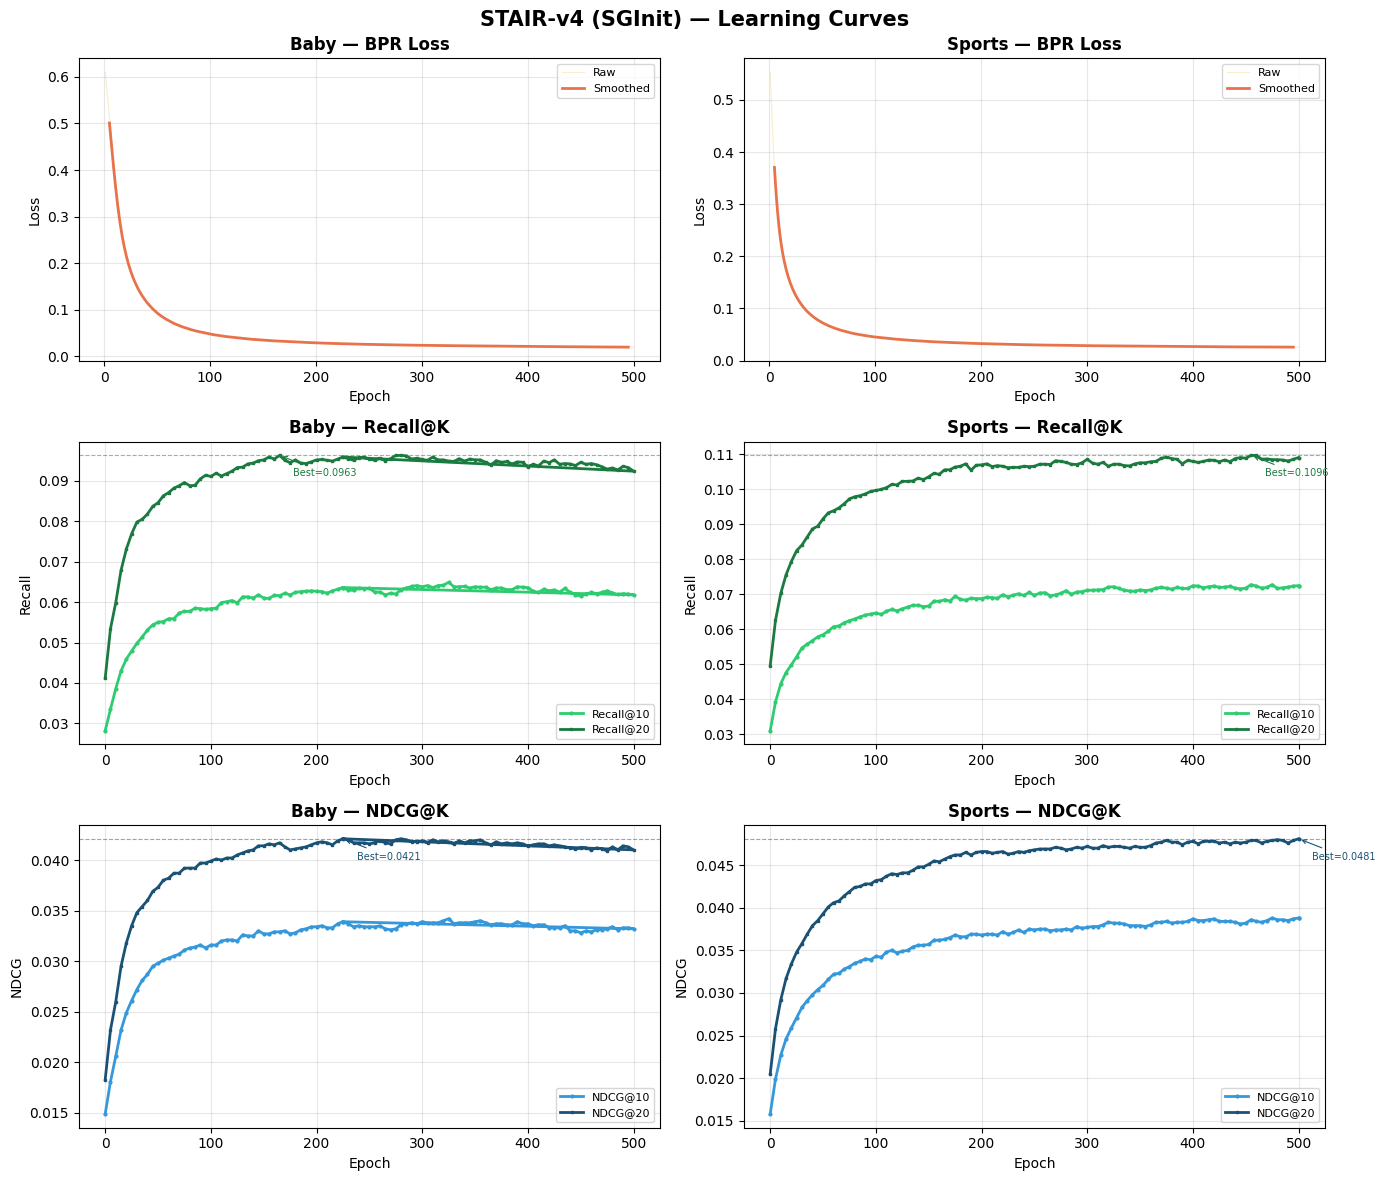

Saved: stair_v4_learning_curves.png


In [10]:
# Cell 7: Learning Curves
import re, os
import numpy as np
import matplotlib.pyplot as plt

def parse_log(log_path):
    if not os.path.exists(log_path): return {}
    with open(log_path, 'r', errors='ignore') as f:
        content = f.read()
    flat = content.replace('\n', ' ')
    loss_eps, losses = [], []
    for m in re.finditer(r'TRAIN @Epoch:\s*(\d+).*?LOSS Avg:\s*([0-9.]+)', flat):
        loss_eps.append(int(m.group(1))); losses.append(float(m.group(2)))
    val_eps, r10, r20, n10, n20 = [], [], [], [], []
    for m in re.finditer(
        r'VALID @Epoch:\s*(\d+).*?RECALL@10 Avg:\s*([0-9.]+).*?'
        r'RECALL@20 Avg:\s*([0-9.]+).*?NDCG@10 Avg:\s*([0-9.]+).*?NDCG@20 Avg:\s*([0-9.]+)', flat):
        val_eps.append(int(m.group(1))); r10.append(float(m.group(2)))
        r20.append(float(m.group(3))); n10.append(float(m.group(4)))
        n20.append(float(m.group(5)))
    return {'loss_eps': loss_eps, 'losses': losses,
            'val_eps': val_eps, 'r10': r10, 'r20': r20, 'n10': n10, 'n20': n20}

def smooth(v, w=10):
    return np.convolve(v, np.ones(w)/w, mode='valid').tolist() if len(v) > w else v

logs = {
    'Baby':   parse_log('/kaggle/working/log_stair_v4_baby.txt'),
    'Sports': parse_log('/kaggle/working/log_stair_v4_sports.txt'),
}

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('STAIR-v4 (SGInit) — Learning Curves', fontsize=15, fontweight='bold')

for ci, ds in enumerate(['Baby', 'Sports']):
    d = logs[ds]
    if not d.get('val_eps'): continue
    m = min(len(d['val_eps']), len(d['r10']), len(d['r20']), len(d['n10']), len(d['n20']))
    ve, r10c, r20c, n10c, n20c = d['val_eps'][:m], d['r10'][:m], d['r20'][:m], d['n10'][:m], d['n20'][:m]

    ax = axes[0][ci]
    if d['losses']:
        s = smooth(d['losses'])
        ax.plot(d['loss_eps'], d['losses'], color='#E8C55A', alpha=0.3, lw=0.8, label='Raw')
        ax.plot(d['loss_eps'][(10-1)//2:(10-1)//2+len(s)], s, color='#E8734A', lw=2, label='Smoothed')
    ax.set_title(f'{ds} — BPR Loss', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    ax = axes[1][ci]
    ax.plot(ve, r10c, color='#2ECC71', lw=2, marker='o', ms=2, label='Recall@10')
    ax.plot(ve, r20c, color='#1A7A3F', lw=2, marker='s', ms=2, label='Recall@20')
    ax.axhline(max(r20c), color='#1A7A3F', ls='--', alpha=0.5, lw=0.8)
    ax.set_title(f'{ds} — Recall@K', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Recall'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.annotate(f'Best={max(r20c):.4f}', xy=(ve[r20c.index(max(r20c))], max(r20c)),
                fontsize=7, color='#1A7A3F', xytext=(10,-15), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='#1A7A3F', lw=0.8))

    ax = axes[2][ci]
    ax.plot(ve, n10c, color='#3498DB', lw=2, marker='o', ms=2, label='NDCG@10')
    ax.plot(ve, n20c, color='#1A5276', lw=2, marker='s', ms=2, label='NDCG@20')
    ax.axhline(max(n20c), color='#1A5276', ls='--', alpha=0.5, lw=0.8)
    ax.set_title(f'{ds} — NDCG@K', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('NDCG'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.annotate(f'Best={max(n20c):.4f}', xy=(ve[n20c.index(max(n20c))], max(n20c)),
                fontsize=7, color='#1A5276', xytext=(10,-15), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='#1A5276', lw=0.8))

plt.tight_layout()
plt.savefig('/kaggle/working/stair_v4_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: stair_v4_learning_curves.png')


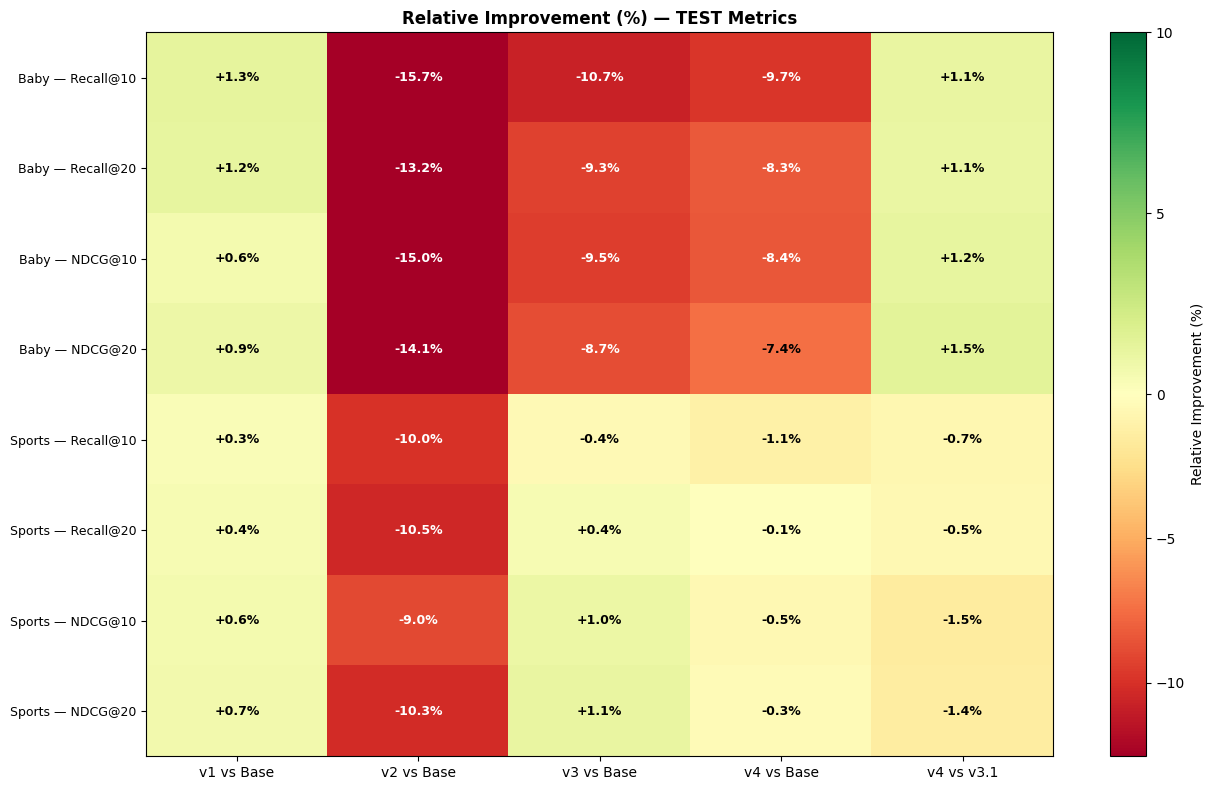

Saved: stair_v4_heatmap.png


In [11]:
# Cell 8: Improvement Heatmap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

comparisons = [
    ('v1 vs Base',  V1_GCL,      BASELINE),
    ('v2 vs Base',  V2_DYFUSE,   BASELINE),
    ('v3 vs Base',  V3_CLIPFUSE, BASELINE),
    ('v4 vs Base',  V4_SGINIT,   BASELINE),
    ('v4 vs v3.1',  V4_SGINIT,   V3_CLIPFUSE),
]
rows = [f'{ds} — {m}' for ds in ['Baby', 'Sports'] for m in METRICS]
cols = [c[0] for c in comparisons]
data = np.zeros((len(rows), len(cols)))

for ci, (_, model, ref) in enumerate(comparisons):
    ri = 0
    for ds in ['Baby', 'Sports']:
        for metric in METRICS:
            m_val = model.get(ds, {}).get(metric, float('nan'))
            r_val = ref.get(ds, {}).get(metric, 1e-9)
            data[ri, ci] = (m_val - r_val) / r_val * 100 if not (m_val != m_val) else 0
            ri += 1

vmax = max(10, np.nanmax(data) * 0.8)
vmin = min(-10, np.nanmin(data) * 0.8)
fig, ax = plt.subplots(figsize=(13, 8))
im = ax.imshow(data, cmap='RdYlGn', aspect='auto',
               norm=mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax))
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, fontsize=10)
ax.set_yticks(range(len(rows))); ax.set_yticklabels(rows, fontsize=9)
plt.colorbar(im, ax=ax, label='Relative Improvement (%)')
for i in range(len(rows)):
    for j in range(len(cols)):
        val = data[i, j]
        ax.text(j, i, f'{val:+.1f}%', ha='center', va='center', fontsize=9,
                fontweight='bold', color='white' if abs(val) > 8 else 'black')
ax.set_title('Relative Improvement (%) — TEST Metrics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/stair_v4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: stair_v4_heatmap.png')


In [12]:
# Cell 9: Final Summary
import os

print('=' * 70)
print('STAIR-v4 (SGInit) — Final TEST Results')
print('=' * 70)

for ds, test in [('Baby', baby_test), ('Sports', sports_test)]:
    if test is None: print(f'[{ds}] No results found'); continue
    base = BASELINE[ds]
    v31  = V3_CLIPFUSE[ds]
    print(f'\n[{ds}]')
    for metric in METRICS:
        v4  = test.get(metric, 0)
        bl  = base[metric]
        v3v = v31[metric]
        d_base = (v4 - bl) / bl * 100
        d_v3   = (v4 - v3v) / v3v * 100
        flag = '✓ BETTER than Baseline' if v4 >= bl else '△ vs Baseline'
        print(f'  {metric:<12}: v4={v4:.6f}  baseline={bl:.6f}  '
              f'Δbase={d_base:+.2f}%  Δv3.1={d_v3:+.2f}%  {flag}')

print('\n' + '=' * 70)
for fp in ['/kaggle/working/stair_v4_learning_curves.png',
           '/kaggle/working/stair_v4_heatmap.png',
           '/kaggle/working/log_stair_v4_baby.txt',
           '/kaggle/working/log_stair_v4_sports.txt']:
    sz = os.path.getsize(fp)/1024 if os.path.exists(fp) else -1
    status = f'{sz:.1f} KB' if sz >= 0 else 'MISSING'
    print(f'  {os.path.basename(fp):<45} {status}')


STAIR-v4 (SGInit) — Final TEST Results

[Baby]
  Recall@10   : v4=0.061900  baseline=0.068560  Δbase=-9.71%  Δv3.1=+1.14%  △ vs Baseline
  Recall@20   : v4=0.094800  baseline=0.103420  Δbase=-8.33%  Δv3.1=+1.07%  △ vs Baseline
  NDCG@10     : v4=0.033300  baseline=0.036335  Δbase=-8.35%  Δv3.1=+1.22%  △ vs Baseline
  NDCG@20     : v4=0.041800  baseline=0.045143  Δbase=-7.41%  Δv3.1=+1.46%  △ vs Baseline

[Sports]
  Recall@10   : v4=0.073500  baseline=0.074310  Δbase=-1.09%  Δv3.1=-0.68%  △ vs Baseline
  Recall@20   : v4=0.111800  baseline=0.111900  Δbase=-0.09%  Δv3.1=-0.53%  △ vs Baseline
  NDCG@10     : v4=0.040000  baseline=0.040200  Δbase=-0.50%  Δv3.1=-1.48%  △ vs Baseline
  NDCG@20     : v4=0.049900  baseline=0.050050  Δbase=-0.30%  Δv3.1=-1.38%  △ vs Baseline

  stair_v4_learning_curves.png                  250.6 KB
  stair_v4_heatmap.png                          123.7 KB
  log_stair_v4_baby.txt                         79.2 KB
  log_stair_v4_sports.txt                       85.9